# Melbourne Liveability Index - Exploratory Data Analysis

This notebook explores the distributions, correlations, and patterns in the liveability metrics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

from ingestion.base import get_db_connection


# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [3]:
# Fetch data from database
conn = get_db_connection()
query = """
SELECT
    s.name,
    cs.rate_per_100k,
    ts.stop_count,
    ts.nearest_train_km,
    ss.avg_icsea_score,
    gs.green_pct_of_suburb,
    pp.median_house_price,
    ls.score_total
FROM suburbs s
LEFT JOIN crime_stats cs ON cs.suburb_id = s.id
LEFT JOIN transport_scores ts ON ts.suburb_id = s.id
LEFT JOIN school_scores ss ON ss.suburb_id = s.id
LEFT JOIN greenspace_scores gs ON gs.suburb_id = s.id
LEFT JOIN property_prices pp ON pp.suburb_id = s.id
LEFT JOIN liveability_scores ls ON ls.suburb_id = s.id
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f"Loaded {len(df)} suburbs")
print(f"\nData shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")

C:\Users\Darrell\AppData\Local\Temp\ipykernel_108792\2339353343.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


Loaded 673 suburbs

Data shape: (673, 8)

Missing values:
name                     0
rate_per_100k            4
stop_count               0
nearest_train_km         0
avg_icsea_score        228
green_pct_of_suburb      0
median_house_price     230
score_total              0
dtype: int64


## Data Coverage

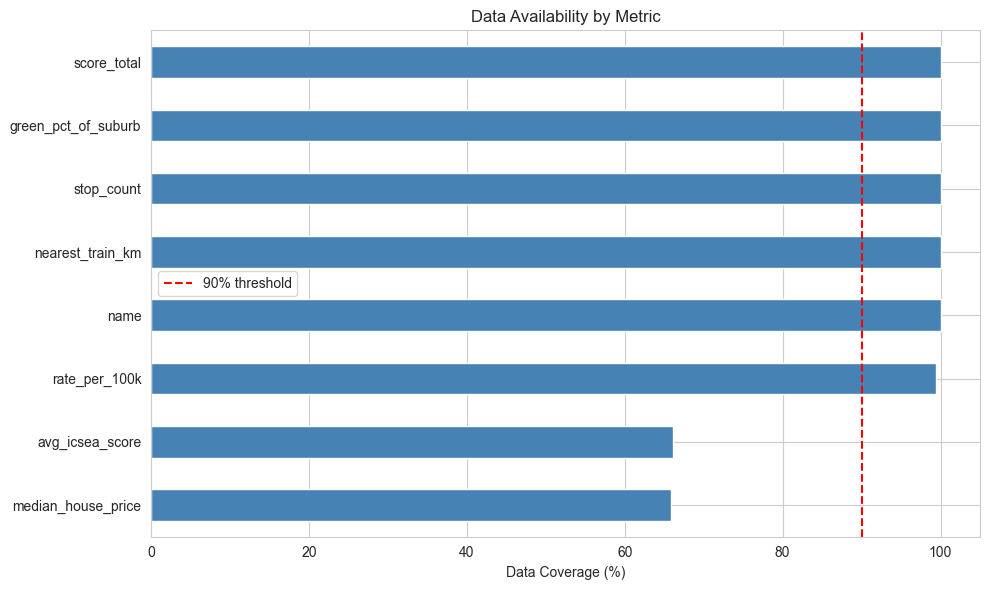

Data Coverage Summary:
name                   100.00
rate_per_100k           99.41
stop_count             100.00
nearest_train_km       100.00
avg_icsea_score         66.12
green_pct_of_suburb    100.00
median_house_price      65.82
score_total            100.00
dtype: float64


In [4]:
# Calculate coverage percentage
coverage = (df.notna().sum() / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
coverage.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Data Coverage (%)')
ax.set_title('Data Availability by Metric')
ax.axvline(x=90, color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("Data Coverage Summary:")
print(coverage)

## Score Distributions

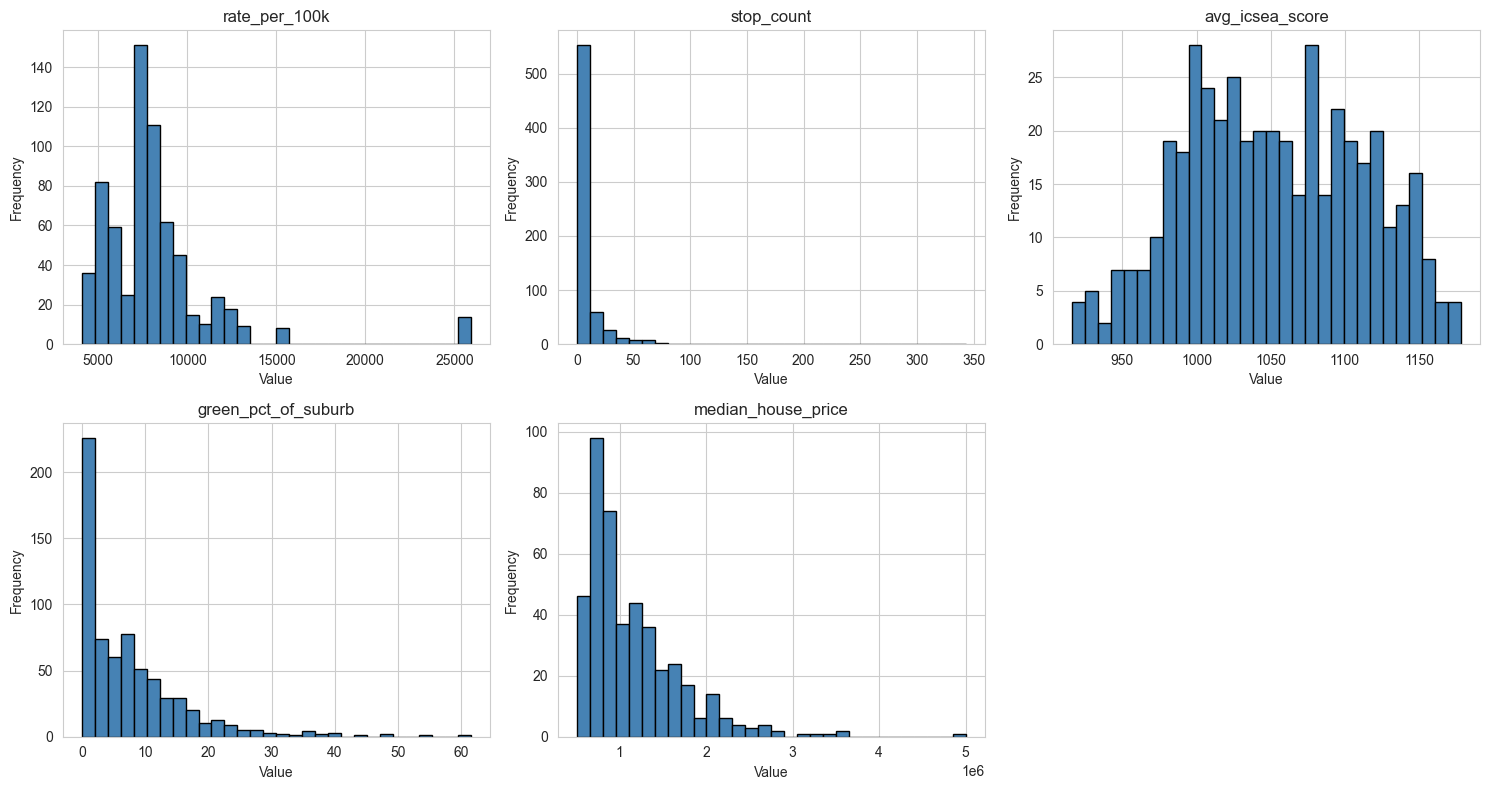


Metric Statistics:
       rate_per_100k  stop_count  avg_icsea_score  green_pct_of_suburb  \
count         669.00      673.00           445.00               673.00   
mean         8118.40        6.69          1052.13                 7.52   
std          3364.98       19.79            59.64                 8.59   
min          4080.93        0.00           916.00                 0.00   
25%          5736.80        0.00          1005.00                 0.87   
50%          7699.44        0.00          1049.60                 5.25   
75%          8627.11        3.00          1100.00                11.21   
max         25908.99      343.00          1178.00                61.48   

       median_house_price  
count              443.00  
mean           1157579.46  
std             567932.36  
min             505000.00  
25%             749500.00  
50%             960000.00  
75%            1394000.00  
max            5000000.00  


In [5]:
# Plot score distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

metrics = ['rate_per_100k', 'stop_count', 'avg_icsea_score', 'green_pct_of_suburb', 'median_house_price']

for idx, metric in enumerate(metrics):
    axes[idx].hist(df[metric].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{metric}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

# Hide the last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print("\nMetric Statistics:")
print(df[metrics].describe().round(2))

## Correlation Analysis

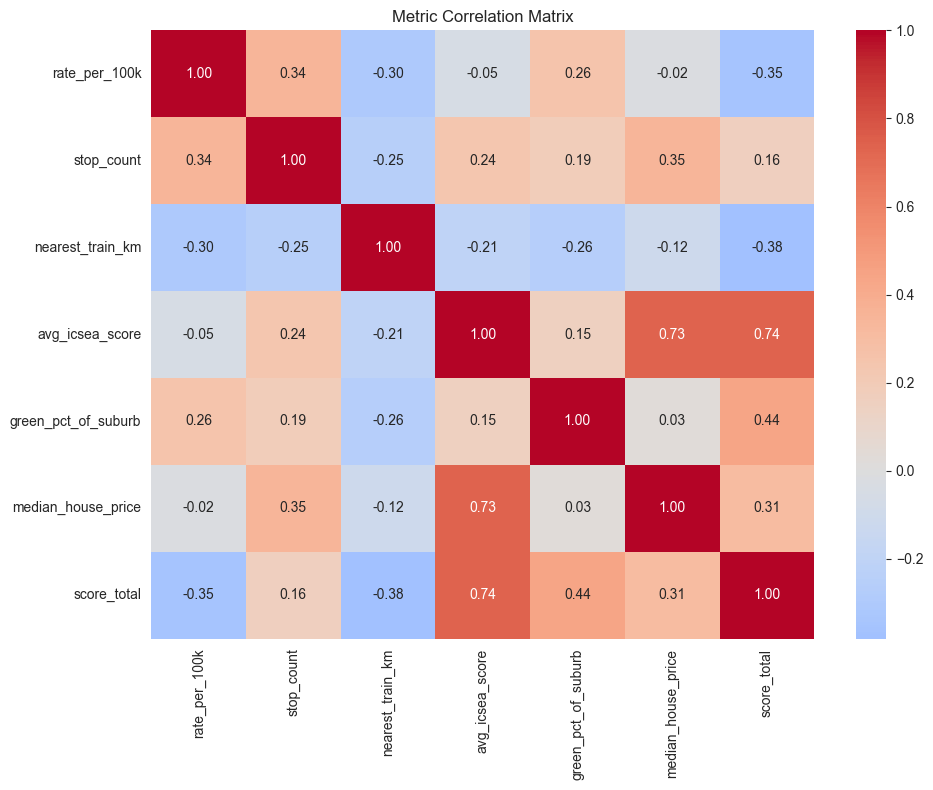


Strong Correlations (|r| > 0.5):
avg_icsea_score <-> median_house_price: 0.732
avg_icsea_score <-> score_total: 0.738


In [6]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Metric Correlation Matrix')
plt.tight_layout()
plt.show()

# Find strong correlations (excluding diagonal)
print("\nStrong Correlations (|r| > 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"{col1} <-> {col2}: {corr_val:.3f}")

## Overall Liveability Distribution

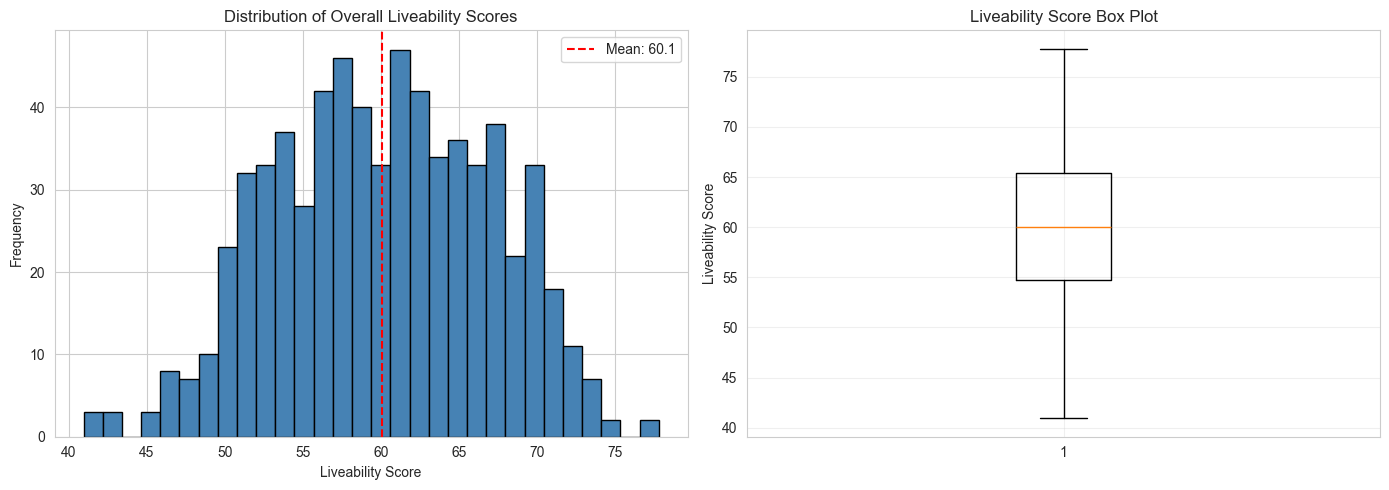


Liveability Score Statistics:
count    673.00
mean      60.08
std        6.84
min       40.94
25%       54.70
50%       59.97
75%       65.42
max       77.78
Name: score_total, dtype: float64

Top 10 Most Liveable Suburbs:
              name  score_total
          Kew East        77.78
          Viewbank        76.85
       Templestowe        75.28
    Burwood (Vic.)        75.18
         Ashburton        73.94
         Blackburn        73.27
       Murrumbeena        73.19
Albert Park (Vic.)        73.10
  Glen Iris (Vic.)        73.07
           Bulleen        73.04

Bottom 10 Least Liveable Suburbs:
           name  score_total
North Melbourne        40.94
     Bona Vista        41.34
 Carlton (Vic.)        41.77
     Marysville        42.22
 West Melbourne        42.57
    South Wharf        43.24
     Tootgarook        45.15
     Flemington        45.63
   Neerim South        45.70
    Ripplebrook        46.26


In [7]:
# Plot score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['score_total'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Liveability Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Overall Liveability Scores')
axes[0].axvline(df['score_total'].mean(), color='red', linestyle='--', label=f'Mean: {df["score_total"].mean():.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['score_total'].dropna())
axes[1].set_ylabel('Liveability Score')
axes[1].set_title('Liveability Score Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLiveability Score Statistics:")
print(df['score_total'].describe().round(2))
print(f"\nTop 10 Most Liveable Suburbs:")
print(df.nlargest(10, 'score_total')[['name', 'score_total']].to_string(index=False))
print(f"\nBottom 10 Least Liveable Suburbs:")
print(df.nsmallest(10, 'score_total')[['name', 'score_total']].to_string(index=False))

## Key Insights

In [8]:
print("\n=== KEY INSIGHTS ===")
print(f"\n1. Data Coverage:")
print(f"   - Best coverage: {coverage.idxmax()} ({coverage.max():.1f}%)")
print(f"   - Worst coverage: {coverage.idxmin()} ({coverage.min():.1f}%)")

print(f"\n2. Liveability Score Range:")
print(f"   - Min: {df['score_total'].min():.1f}")
print(f"   - Max: {df['score_total'].max():.1f}")
print(f"   - Mean: {df['score_total'].mean():.1f}")
print(f"   - Std Dev: {df['score_total'].std():.1f}")

print(f"\n3. Strongest Metric Correlations with Total Score:")
if 'score_total' in corr_matrix.columns:
    score_corr = corr_matrix['score_total'].sort_values(ascending=False)
    for metric, corr_val in score_corr[1:6].items():
        print(f"   - {metric}: {corr_val:.3f}")


=== KEY INSIGHTS ===

1. Data Coverage:
   - Best coverage: name (100.0%)
   - Worst coverage: median_house_price (65.8%)

2. Liveability Score Range:
   - Min: 40.9
   - Max: 77.8
   - Mean: 60.1
   - Std Dev: 6.8

3. Strongest Metric Correlations with Total Score:
   - avg_icsea_score: 0.738
   - green_pct_of_suburb: 0.443
   - median_house_price: 0.306
   - stop_count: 0.160
   - rate_per_100k: -0.353
